# 🎙️ Regresión Logística Multiclase — One-vs-All (OvR)
## Dataset: Spoken Arabic Digit

Grabaciones de 88 hablantes árabes diciendo dígitos del 0 al 9.  
De cada grabación se extraen **13 coeficientes MFCC** (características del sonido).  
Objetivo: **predecir qué dígito se pronunció** → clasificación multiclase con **One-vs-All**.

| Propiedad | Valor |
|---|---|
| Ejemplos | 8,800 |
| Features | 13 MFCC |
| Clases | 10 (dígitos 0–9) |
| Balance | 880 por clase |

## 1.  Importar librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
%matplotlib inline

## 2.  Cargar Dataset con Pandas

Usamos **Pandas** para explorar y preparar los datos porque permite:
- Ver y entender el dataset fácilmente (`head`, `describe`, `value_counts`)
- Balancear clases con `groupby + sample`
- Seleccionar columnas por nombre (`df[feature_cols]`)

Luego convertimos a **NumPy** para el modelo (más rápido en operaciones matriciales).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Universida/IA/Dataset/spoken_arabic_digit.csv')
print(df.shape)
df.head(3)

Mounted at /content/drive
(8800, 14)


,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13,digit
0,-10.941945,-0.863998,-0.527611,3.741830,-2.484684,1.033847,-3.036231,3.035132,-0.061478,1.845235,-2.154537,-0.101948,-2.017274,4
1,-4.516921,4.980269,-3.757552,0.452769,-0.443991,3.663932,-0.676390,1.059985,-2.025810,0.676322,-0.517093,0.810290,-1.516750,9
2,-7.941746,3.689850,-2.655734,2.029304,-2.613914,1.340046,-0.304583,1.659404,-1.010461,1.748062,-1.180417,-0.054728,0.056356,0


## 3.  Preprocesamiento con Pandas
**Pasos:** balancear → separar X/y → split 80/20 → escalar → expandir features

>  `StandardScaler` se ajusta **solo en train** y se aplica en test.  
> Si usáramos todo el dataset, el modelo vería datos de test antes de evaluarse (data leakage).

In [ ]:
# Balancear: mismo número de ejemplos por clase (undersampling con Pandas)
n_min  = df['digit'].value_counts().min()
df_bal = df.groupby('digit', group_keys=False).apply(lambda g: g.sample(n=n_min, random_state=42))
df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Balanceado: {n_min} por clase | Total: {len(df_bal)}')

Balanceado: 880 por clase | Total: 8800


/tmp/ipykernel_16857/1173462758.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_bal = df.groupby('digit', group_keys=False).apply(lambda g: g.sample(n=n_min, random_state=42))


In [ ]:
# Separar X / y con Pandas, luego split 80/20
feature_cols        = [c for c in df_bal.columns if c.startswith('MFCC')]
X_df, y_df          = df_bal[feature_cols], df_bal['digit']
X_tr, X_te, y_tr, y_te = train_test_split(X_df, y_df, test_size=0.2, random_state=42, stratify=y_df)
print(f'Train: {X_tr.shape} | Test: {X_te.shape}')

Train: (7040, 13) | Test: (1760, 13)


In [ ]:
# Escalar (fit solo en train) + expandir a features polinómicas grado 2
# 13 features originales → 104 combinaciones cuadráticas
scaler = StandardScaler()
poly   = PolynomialFeatures(degree=2, include_bias=False)

X_train = poly.fit_transform(scaler.fit_transform(X_tr.values))
X_test  = poly.transform(scaler.transform(X_te.values))
y_train, y_test = y_tr.values, y_te.values
num_labels = len(np.unique(y_train))

print(f'Features: 13 → {X_train.shape[1]} (poly grado 2) | Clases: {num_labels}')

Features: 13 → 104 (poly grado 2) | Clases: 10


## 4.  Exploración Visual del Dataset

**Gráfica izquierda — Distribución de clases:**  
Confirma que el dataset está balanceado. Si las barras fueran muy desiguales, el modelo aprendería mejor los dígitos con más datos y peor los que tienen pocos.

**Gráfica derecha — Heatmap de medias MFCC:**  
Cada fila es la firma espectral de un dígito. Si las filas son distintas entre sí → el modelo puede separarlos. Colores muy similares entre filas = dígitos difíciles de distinguir.

In [ ]:
# Preparar datos para las gráficas
conteo       = pd.Series(y_train).value_counts().sort_index()
colores_tab  = plt.cm.tab10(np.linspace(0, 1, num_labels))
X_tr_sc      = scaler.transform(X_tr.values)   # escala original (13 features)
medias_mfcc  = np.array([X_tr_sc[y_train == c].mean(axis=0) for c in range(num_labels)])

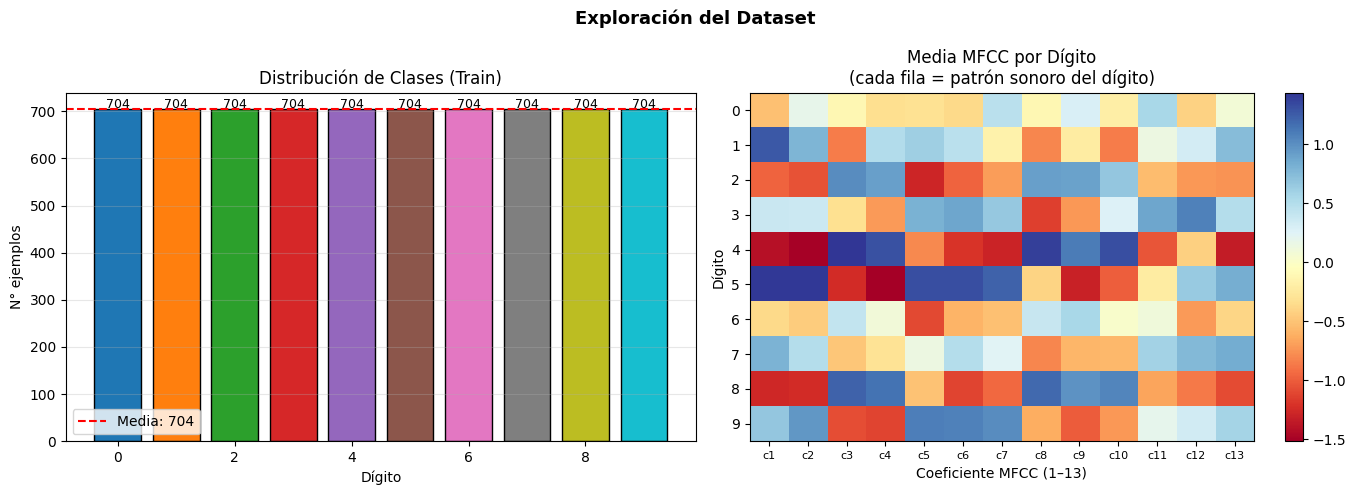

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Exploración del Dataset', fontsize=13, fontweight='bold')

# Barras: distribución de clases
bars = axes[0].bar(conteo.index, conteo.values, color=colores_tab, edgecolor='black')
[axes[0].text(b.get_x()+b.get_width()/2., b.get_height()+3, str(v), ha='center', fontsize=9) for b, v in zip(bars, conteo.values)]
axes[0].axhline(conteo.mean(), color='red', linestyle='--', label=f'Media: {conteo.mean():.0f}')
axes[0].set(title='Distribución de Clases (Train)', xlabel='Dígito', ylabel='N° ejemplos')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Heatmap: firma espectral por dígito
im = axes[1].imshow(medias_mfcc, aspect='auto', cmap='RdYlBu')
axes[1].set(title='Media MFCC por Dígito\n(cada fila = patrón sonoro del dígito)',
            xlabel='Coeficiente MFCC (1–13)', ylabel='Dígito')
axes[1].set_yticks(range(10)); axes[1].set_xticks(range(13))
axes[1].set_xticklabels([f'c{i+1}' for i in range(13)], fontsize=8)
plt.colorbar(im, ax=axes[1])

plt.tight_layout(); plt.show()

## 5.  Función Sigmoide

La regresión logística no predice 0 o 1 directamente, sino una **probabilidad** entre 0 y 1:

$$g(z) = \frac{1}{1 + e^{-z}} \quad \text{donde} \quad z = \theta^T x$$

- $g(z) \geq 0.5$ → predice clase **positiva** (sí es este dígito)
- $g(z) < 0.5$ → predice clase **negativa** (no es este dígito)

**La gráfica** muestra cómo la sigmoide aplasta cualquier número real al rango [0, 1].  
La zona verde es donde el clasificador dice sí, la roja donde dice no.

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

print(f'sigmoid(0)={sigmoid(0)} | sigmoid(10)≈{sigmoid(10):.4f} | sigmoid(-10)≈{sigmoid(-10):.4f}')

sigmoid(0)=0.5 | sigmoid(10)≈1.0000 | sigmoid(-10)≈0.0000


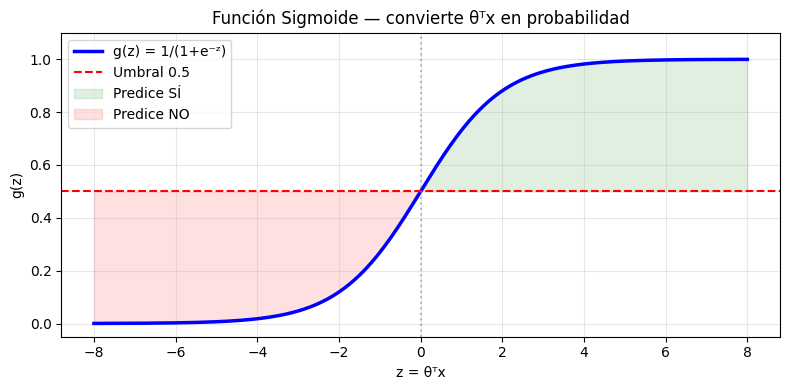

In [ ]:
z = np.linspace(-8, 8, 300)
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(z, sigmoid(z), 'b-', linewidth=2.5, label='g(z) = 1/(1+e⁻ᶻ)')
ax.axhline(0.5, color='red', linestyle='--', label='Umbral 0.5')
ax.axvline(0,   color='gray', linestyle=':', alpha=0.5)
ax.fill_between(z, sigmoid(z), 0.5, where=sigmoid(z)>0.5, alpha=0.12, color='green', label='Predice SÍ')
ax.fill_between(z, sigmoid(z), 0.5, where=sigmoid(z)<0.5, alpha=0.12, color='red',   label='Predice NO')
ax.set(title='Función Sigmoide — convierte θᵀx en probabilidad', xlabel='z = θᵀx', ylabel='g(z)', ylim=(-0.05, 1.1))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6.  Función de Costo Regularizada

El **costo** mide qué tan equivocado está el modelo. Queremos **minimizarlo**:

$$J(\theta) = \underbrace{-\frac{1}{m}\sum\left[y\log h + (1-y)\log(1-h)\right]}_{\text{Cross-Entropy}} + \underbrace{\frac{\lambda}{2m}\sum_{j=1}^n\theta_j^2}_{\text{Regularización L2}}$$

>  **No se regulariza $\theta_0$** (el bias), porque penalizarlo distorsionaría el modelo.

In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    m    = y.size
    h    = sigmoid(X.dot(theta))
    temp = theta.copy(); temp[0] = 0          # no regularizar θ₀
    J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
    grad = (1/m) * (h - y).dot(X) + (lambda_/m) * temp
    return J, grad

# Verificación con valores conocidos
theta_t = np.array([-2,-1,1,2], dtype=float)
X_t     = np.c_[np.ones(5), np.arange(1,16).reshape(5,3,order='F')/10.0]
y_t     = np.array([1,0,1,0,1])
J_v, _  = lrCostFunction(theta_t, X_t, y_t, 3)
print(f'Costo: {J_v:.6f} | Esperado: 2.534819 → {"✓" if abs(J_v-2.534819)<0.001 else "✗"}')

Costo: 2.534819 | Esperado: 2.534819 → ✓


## 7.  Entrenamiento One-vs-All (OvR)

La regresión logística **binaria** solo separa 2 clases.  
Con OvR entrenamos **un clasificador por dígito**:

```
Clasificador 0: ¿Es el 0?  → sí=1, resto=0
Clasificador 1: ¿Es el 1?  → sí=1, resto=0
...                            ...
Clasificador 9: ¿Es el 9?  → sí=1, resto=0
```

Los 10 vectores $\theta^{(k)}$ se guardan como filas de la matriz $\Theta$ → forma $(10 \times n+1)$.  
Para predecir: $\hat{y} = \arg\max_k \; h_{\theta^{(k)}}(x)$ — la clase con mayor probabilidad.

In [ ]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n   = X.shape
    X_b    = np.c_[np.ones(m), X]
    all_theta, historial = np.zeros((num_labels, n+1)), []
    for c in range(num_labels):
        y_c, costos_c = (y == c).astype(int), []
        res = optimize.minimize(lrCostFunction, np.zeros(n+1), args=(X_b, y_c, lambda_),
                                jac=True, method='CG', options={'maxiter': 150},
                                callback=lambda t: costos_c.append(lrCostFunction(t, X_b, y_c, lambda_)[0]))
        all_theta[c] = res.x
        historial.append(costos_c)
        print(f'  Dígito {c}: J_final={costos_c[-1]:.5f} ({len(costos_c)} iters)')
    return all_theta, historial

lambda_ = 0.01
all_theta, historial_costos = oneVsAll(X_train, y_train, num_labels, lambda_)
print(f'✓ Θ shape: {all_theta.shape}')

/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: divide by zero encountered in log
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: invalid value encountered in multiply
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: divide by zero encountered in log
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: invalid value encountered in multiply
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: divide by zero encountered in log
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: invalid value encountered in

  Dígito 0: J_final=nan (150 iters)


/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: divide by zero encountered in log
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: invalid value encountered in multiply
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: divide by zero encountered in log
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: invalid value encountered in multiply
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: divide by zero encountered in log
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: invalid value encountered in

  Dígito 1: J_final=nan (150 iters)
  Dígito 2: J_final=0.03457 (150 iters)
  Dígito 3: J_final=0.01106 (150 iters)
  Dígito 4: J_final=0.07345 (150 iters)


/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: divide by zero encountered in log
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: invalid value encountered in multiply
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: divide by zero encountered in log
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: invalid value encountered in multiply
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: divide by zero encountered in log
  J    = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
/tmp/ipykernel_16857/2884250555.py:5: RuntimeWarning: invalid value encountered in

  Dígito 5: J_final=nan (150 iters)
  Dígito 6: J_final=0.00633 (150 iters)
  Dígito 7: J_final=0.02522 (150 iters)
  Dígito 8: J_final=0.11860 (150 iters)
  Dígito 9: J_final=0.01358 (150 iters)
✓ Θ shape: (10, 105)


## 8.  Curvas de Costo durante el Entrenamiento

Cada curva muestra cómo el costo $J(\theta)$ **decrece** mientras el clasificador aprende.

- **Eje X:** Iteración del optimizador (cada paso ajusta $\theta$)
- **Eje Y:** Valor de $J(\theta)$ — más bajo = mejor
- **Curva descendente** → el modelo converge correctamente
- **Curva plana al final** → llegó al mínimo, ya no puede mejorar más

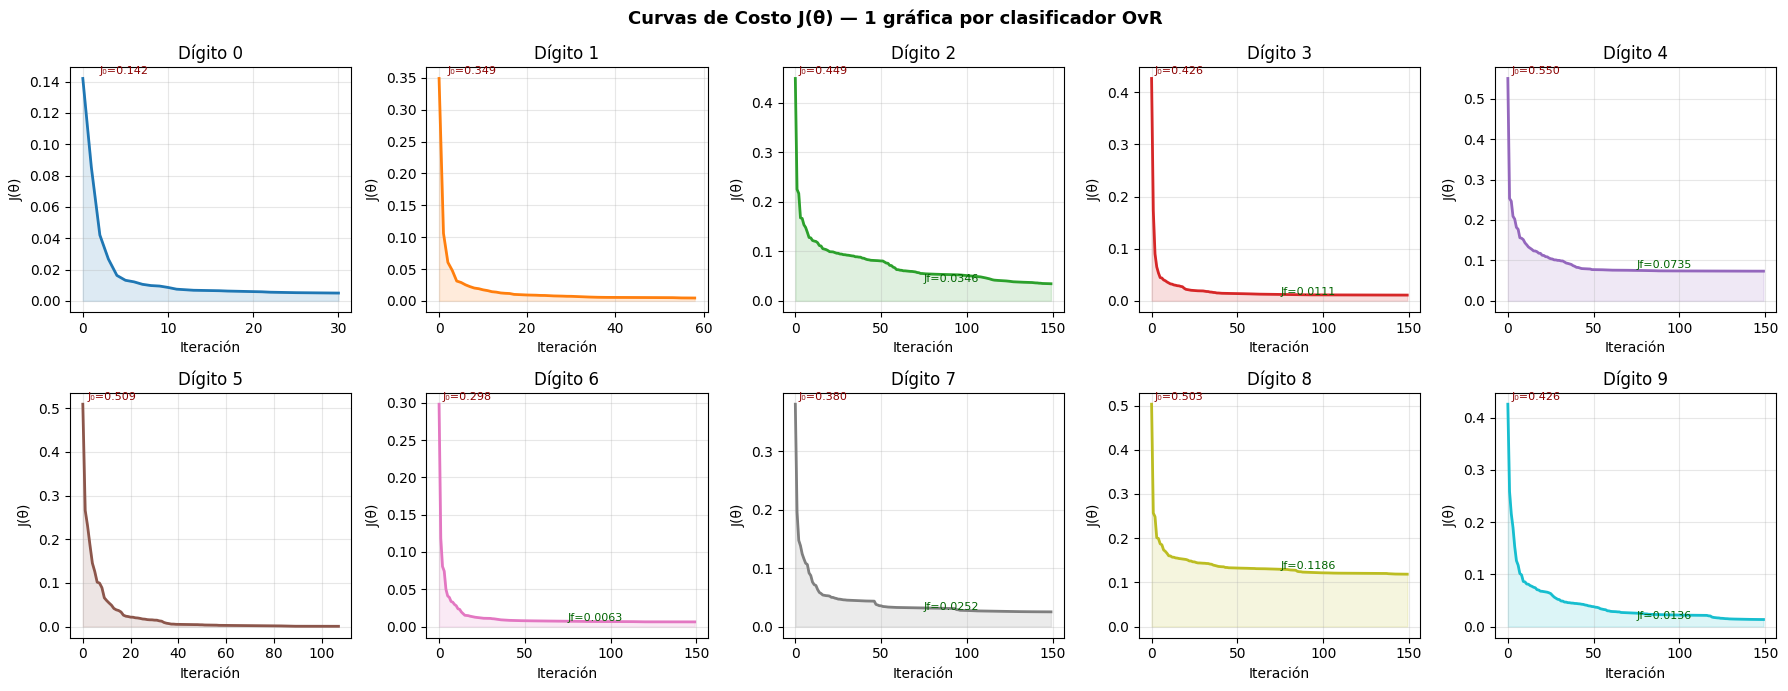

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Curvas de Costo J(θ) — 1 gráfica por clasificador OvR', fontsize=13, fontweight='bold')

for c, ax in enumerate(axes.flatten()):
    costos = historial_costos[c]
    ax.plot(costos, color=colores_tab[c], linewidth=2)
    ax.fill_between(range(len(costos)), costos, alpha=0.15, color=colores_tab[c])
    ax.set(title=f'Dígito {c}', xlabel='Iteración', ylabel='J(θ)')
    ax.annotate(f'J₀={costos[0]:.3f}',  xy=(0, costos[0]),  xytext=(2, costos[0]*1.02),  fontsize=8, color='darkred')
    ax.annotate(f'Jf={costos[-1]:.4f}', xy=(len(costos)-1, costos[-1]), xytext=(len(costos)*0.5, costos[-1]*1.1), fontsize=8, color='darkgreen')
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 9.  Predicción y Evaluación

Para cada ejemplo $x$ se multiplica por toda la matriz $\Theta$ y se aplica sigmoid:

$$P = \sigma(X_b \cdot \Theta^T) \quad \rightarrow \text{matriz } (m \times 10)$$

Cada columna $k$ = probabilidad de ser el dígito $k$.  
La predicción = columna con valor más alto → $\hat{y} = \arg\max$

In [ ]:
def predictOneVsAll(all_theta, X):
    probs = sigmoid(np.c_[np.ones(X.shape[0]), X].dot(all_theta.T))  # (m × K)
    return np.argmax(probs, axis=1), probs

pred_train, _         = predictOneVsAll(all_theta, X_train)
pred_test,  prob_test = predictOneVsAll(all_theta, X_test)
acc_train = np.mean(pred_train == y_train) * 100
acc_test  = np.mean(pred_test  == y_test)  * 100

print(f'Train: {acc_train:.2f}%  |  Test: {acc_test:.2f}%')

Train: 95.06%  |  Test: 91.88%


In [ ]:
print(classification_report(y_test, pred_test, target_names=[f'Dígito {c}' for c in range(10)]))

              precision    recall  f1-score   support

    Dígito 0       0.95      0.95      0.95       176
    Dígito 1       0.99      0.95      0.97       176
    Dígito 2       0.88      0.92      0.90       176
    Dígito 3       0.96      0.91      0.94       176
    Dígito 4       0.84      0.82      0.83       176
    Dígito 5       1.00      0.99      0.99       176
    Dígito 6       0.95      0.95      0.95       176
    Dígito 7       0.90      0.96      0.93       176
    Dígito 8       0.77      0.74      0.76       176
    Dígito 9       0.95      0.98      0.96       176

    accuracy                           0.92      1760
   macro avg       0.92      0.92      0.92      1760
weighted avg       0.92      0.92      0.92      1760



## 10.  Gráficas de Evaluación

**Barras de precisión por clase:** Verde ≥85% (excelente), naranja 70–85% (bueno), rojo <70% (mejorable).

**Matriz de confusión:** Diagonal brillante = aciertos. Una celda oscura fuera de la diagonal significa que el modelo confunde esos dos dígitos frecuentemente.

**Precision / Recall / F1:**
- **Precision:** De los que predije como X, ¿cuántos eran realmente X?
- **Recall:** De los que realmente son X, ¿cuántos predije correctamente?
- **F1:** Balance entre ambas

In [ ]:
# Calcular métricas
cm         = confusion_matrix(y_test, pred_test)
prec_clase = cm.diagonal() / cm.sum(axis=1) * 100
prec_s     = precision_score(y_test, pred_test, average=None) * 100
rec_s      = recall_score(y_test,  pred_test, average=None)   * 100
f1_s       = f1_score(y_test,      pred_test, average=None)   * 100
colores_p  = ['#43A047' if p>=85 else '#FB8C00' if p>=70 else '#E53935' for p in prec_clase]
print(f'F1 promedio: {f1_s.mean():.2f}%')

F1 promedio: 91.86%


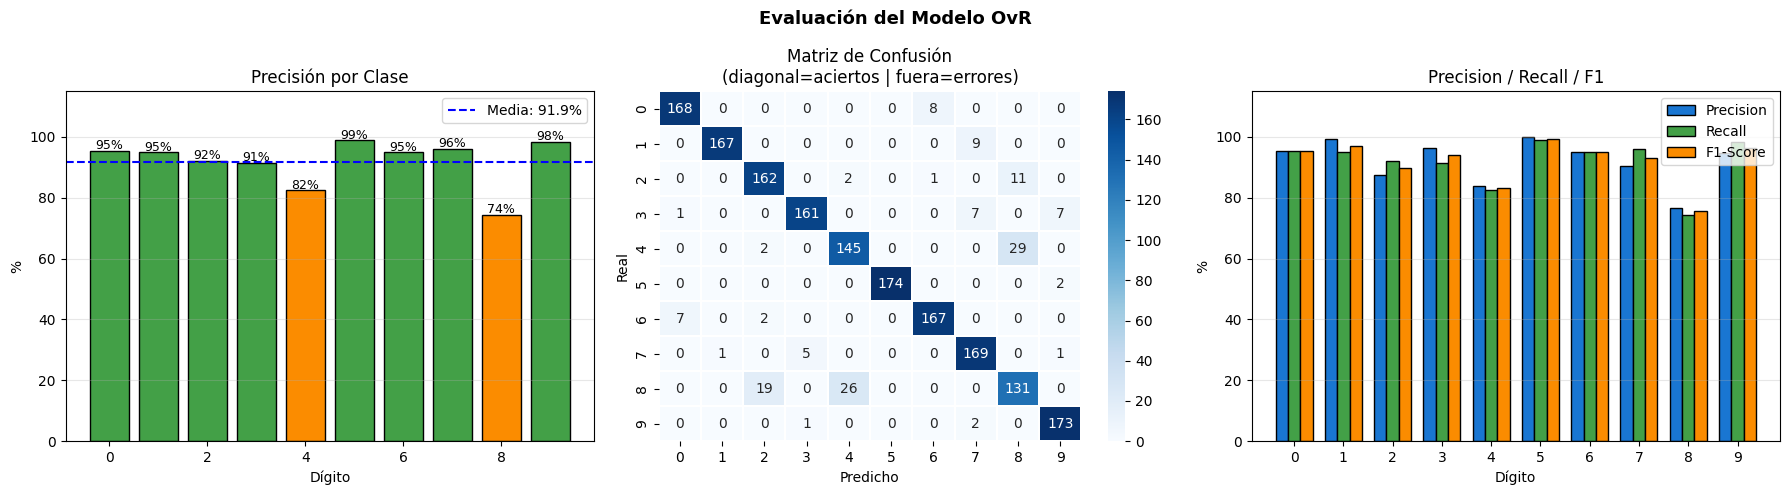

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluación del Modelo OvR', fontsize=13, fontweight='bold')

# Barras: precisión por clase
bars = axes[0].bar(range(10), prec_clase, color=colores_p, edgecolor='black')
[axes[0].text(b.get_x()+b.get_width()/2., b.get_height()+0.5, f'{p:.0f}%', ha='center', fontsize=9) for b, p in zip(bars, prec_clase)]
axes[0].axhline(acc_test, color='blue', linestyle='--', label=f'Media: {acc_test:.1f}%')
axes[0].set(title='Precisión por Clase', xlabel='Dígito', ylabel='%', ylim=[0,115])
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Heatmap: matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=range(10), yticklabels=range(10), linewidths=0.3)
axes[1].set(title='Matriz de Confusión\n(diagonal=aciertos | fuera=errores)', xlabel='Predicho', ylabel='Real')

# Barras agrupadas: Precision / Recall / F1
x = np.arange(10); w = 0.25
axes[2].bar(x-w, prec_s, w, label='Precision', color='#1976D2', edgecolor='black')
axes[2].bar(x,   rec_s,  w, label='Recall',    color='#43A047', edgecolor='black')
axes[2].bar(x+w, f1_s,   w, label='F1-Score',  color='#FB8C00', edgecolor='black')
axes[2].set(title='Precision / Recall / F1', xlabel='Dígito', ylabel='%', ylim=[0,115])
axes[2].set_xticks(x); axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

## 11.  ¿Cómo decide el modelo? — Probabilidades OvR

Para cada ejemplo el modelo calcula **10 probabilidades** y elige la más alta.

-  **Verde** = dígito predicho (barra más alta)
-  **Azul** = dígito real
- Mismo color → **✓** | Colores distintos → **✗**

Un modelo **seguro** tiene UNA barra muy alta. Un modelo **inseguro** tiene varias barras similares.

In [ ]:
# Seleccionar 8 muestras aleatorias del test
np.random.seed(42)
indices = np.random.choice(len(X_test), 8, replace=False)

/tmp/ipykernel_16857/3187874645.py:15: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_16857/3187874645.py:15: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


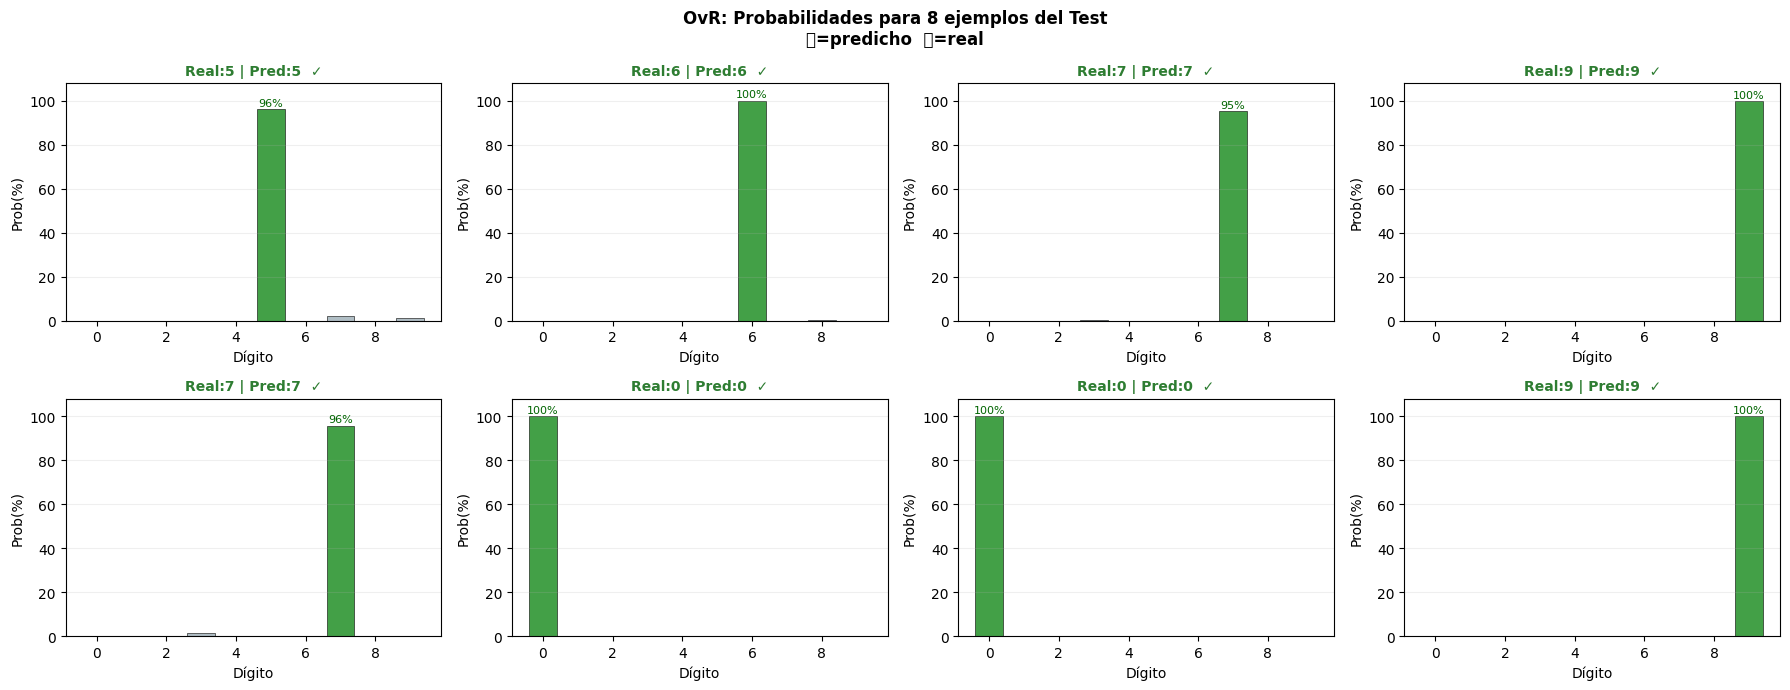

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('OvR: Probabilidades para 8 ejemplos del Test\n🟢=predicho  🔵=real', fontsize=12, fontweight='bold')

for ax, i in zip(axes.flatten(), indices):
    real, probs = y_test[i], prob_test[i] * 100
    pred  = np.argmax(probs)
    bar_c = ['#43A047' if c==pred else '#1976D2' if c==real else '#B0BEC5' for c in range(10)]
    ax.bar(range(10), probs, color=bar_c, edgecolor='black', linewidth=0.4)
    ax.set_title(f'Real:{real} | Pred:{pred}  {"✓" if real==pred else "✗"}',
                 color='#2E7D32' if real==pred else '#C62828', fontweight='bold', fontsize=10)
    ax.set(xlabel='Dígito', ylabel='Prob(%)', ylim=[0,108])
    ax.text(pred, probs[pred]+1.5, f'{probs[pred]:.0f}%', ha='center', fontsize=8, color='darkgreen')
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout(); plt.show()

In [ ]:
print(f'Precisión Train : {acc_train:.2f}%')
print(f'Precisión Test  : {acc_test:.2f}%')
print(f'F1 promedio     : {f1_s.mean():.2f}%')

Precisión Train : 95.06%
Precisión Test  : 91.88%
F1 promedio     : 91.86%
